In [1]:
import os
import argparse
from types import SimpleNamespace
from pathlib import Path

import cortex

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import io, warnings
from contextlib import contextmanager, redirect_stdout, redirect_stderr

@contextmanager
def suppress_print():
    """Silence stdout/stderr and warnings inside the with-block."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        f, e = io.StringIO(), io.StringIO()
        with redirect_stdout(f), redirect_stderr(e):
            yield

os.chdir("/engram/nklab/pf2477/brain_decoding/")
from brain_adapter.dataset import nsd_topk_parcel_dataset, get_dominant_roi_per_parcel

In [2]:
import shutil, os, subprocess as sp
import re

def robust_inkscape_version():
    env = os.environ.copy()
    env.setdefault('LANG','C.UTF-8'); env.setdefault('LC_ALL','C.UTF-8')
    p = sp.run(['inkscape','--version'], stdout=sp.PIPE, stderr=sp.STDOUT, text=True, env=env)
    m = re.search(r'Inkscape\s+([0-9]+(?:\.[0-9]+)*)', p.stdout or "")
    return m.group(1) if m else '0'   # fallback minimal

import cortex, cortex.svgoverlay as svo
svo.INKSCAPE_VERSION = robust_inkscape_version()
print("Patched INKSCAPE_VERSION =", svo.INKSCAPE_VERSION)

Patched INKSCAPE_VERSION = 1.3


In [3]:
subj=1
args = SimpleNamespace(
        subj=subj,
        backbone_arch="dinov2_q",
        data_dir="/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data",
        imgs_dir="/engram/nklab/datasets/natural_scene_dataset/nsddata_stimuli/stimuli/nsd",
        parcel_dir="/engram/nklab/algonauts/ethan/whole_brain_encoder/parcels/schaefer",
        hemi=None,
)
args.tokenizer = None
args.gen_size = 512
args.topk = 100
print("Setting up test configuration for subject ", subj)

print("\n" + "="*50)
print("Testing nsd_topk_parcel_dataset (single subject)")
print("="*50)
train_dataset = nsd_topk_parcel_dataset(args, split='train', transform=None, topk=args.topk)
print(len(train_dataset), "samples in the dataset")
print(train_dataset.selected_parcel_idx)
print(len(train_dataset.selected_parcel_idx['lh']), "left hemisphere parcels")
print(len(train_dataset.selected_parcel_idx['rh']), "right hemisphere parcels")

Setting up test configuration for subject  1

Testing nsd_topk_parcel_dataset (single subject)
Training on subject: 1
9000 samples in the dataset
{'lh': array([  2,  21,  26,  27,  11,   0,   1, 157,   3, 158,  45,  24, 160,
        22,   9,  14, 151,  41,  20,  28,  18, 161,  15, 475,  32, 473,
         8, 159,  23, 163,  31,  17,  25, 166,  44, 164,  19, 467,  10,
       181,  29,  47, 155,   6, 154, 469, 156,   5,  12, 210, 476, 162,
        13, 170,  16, 167,  30,  33, 477,   7, 493, 370, 468, 369, 149,
        56, 377, 367,  46, 171, 213, 165, 172,   4, 153, 481, 495, 152,
       435, 182, 186, 323, 497, 174, 173, 358, 150, 482, 237, 471, 474,
        52, 247, 198, 483, 396, 325, 271, 184, 196]), 'rh': array([ 35,  39,  21,  10, 153,  37, 155,   2,  23,   4,   0, 154,  20,
       152,  42,  19, 151,  15,  36,   8, 302,  13,  43,  28,  41,  29,
       308,  17,  25, 147,   9,  24,  18, 390, 424,  14, 496,   1,  49,
        40, 162, 161, 305, 453, 389,  16, 333, 163, 175,  31, 149, 

In [4]:
neural_data_path = Path(
        "/engram/nklab/datasets/natural_scene_dataset/model_training_datasets/neural_data"
    )
metadata = np.load(
    neural_data_path / f"metadata_sub-{subj:02}.npy", allow_pickle=True
).item()

all_roi_names = list(metadata['lh_rois'].keys())[:24] + list(metadata['rh_rois'].keys())[:24]
print(f' all_roi_names: {all_roi_names}, len: {len(all_roi_names)}')

roi = all_roi_names[0]
print(metadata['lh_rois'][roi])
print(len(metadata['lh_rois'][roi]))
# print([id for id, val in enumerate(metadata['lh_rois'][roi]) if val == True])

min_overlap_threshold = 0.5
dominant_rois = get_dominant_roi_per_parcel(train_dataset, metadata, all_roi_names, min_overlap_threshold=min_overlap_threshold)

print("\n" + "="*50)
print("DOMINANT ROI PER PARCEL (>10% overlap)")
print("="*50)

for hemi in ['lh', 'rh']:
    print(f"\n{hemi.upper()} Hemisphere:")
    cnt = 0
    for parcel_idx, roi_name, overlap, num_voxels in dominant_rois[hemi]:
        if roi_name:
            print(f"Parcel {parcel_idx:3d}: {roi_name:20s} ({overlap:.1%}) in {num_voxels} Schaefer voxels")
            cnt += 1
        else:
            print(f"Parcel {parcel_idx:3d}: No ROI has >= {min_overlap_threshold:.1%} overlap")

    print(f"Total parcels with dominant ROI in {hemi.upper()}: {cnt}")

 all_roi_names: ['V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words', 'V1v', 'V1d', 'V2v', 'V2d', 'V3v', 'V3d', 'hV4', 'EBA', 'FBA-1', 'FBA-2', 'mTL-bodies', 'OFA', 'FFA-1', 'FFA-2', 'mTL-faces', 'aTL-faces', 'OPA', 'PPA', 'RSC', 'OWFA', 'VWFA-1', 'VWFA-2', 'mfs-words', 'mTL-words'], len: 48
[False False False ... False False False]
163842
Processing 100 LH parcels with matrix operations...


LH: 100%|██████████| 100/100 [00:00<00:00, 280.54it/s]


Processing 100 RH parcels with matrix operations...


RH: 100%|██████████| 100/100 [00:00<00:00, 287.68it/s]


DOMINANT ROI PER PARCEL (>10% overlap)

LH Hemisphere:
Parcel   2: V1d                  (67.9%) in 184 Schaefer voxels
Parcel  21: EBA                  (100.0%) in 293 Schaefer voxels
Parcel  26: V2d                  (81.8%) in 192 Schaefer voxels
Parcel  27: V3d                  (52.0%) in 204 Schaefer voxels
Parcel  11: V2v                  (55.4%) in 408 Schaefer voxels
Parcel   0: V1v                  (55.0%) in 318 Schaefer voxels
Parcel   1: V1v                  (87.1%) in 233 Schaefer voxels
Parcel 157: EBA                  (95.5%) in 336 Schaefer voxels
Parcel   3: V1d                  (100.0%) in 241 Schaefer voxels
Parcel 158: EBA                  (100.0%) in 85 Schaefer voxels
Parcel  45: PPA                  (100.0%) in 381 Schaefer voxels
Parcel  24: V3d                  (54.0%) in 326 Schaefer voxels
Parcel 160: EBA                  (91.5%) in 201 Schaefer voxels
Parcel  22: V1d                  (69.3%) in 218 Schaefer voxels
Parcel   9: No ROI has >= 50.0% overlap
Parce

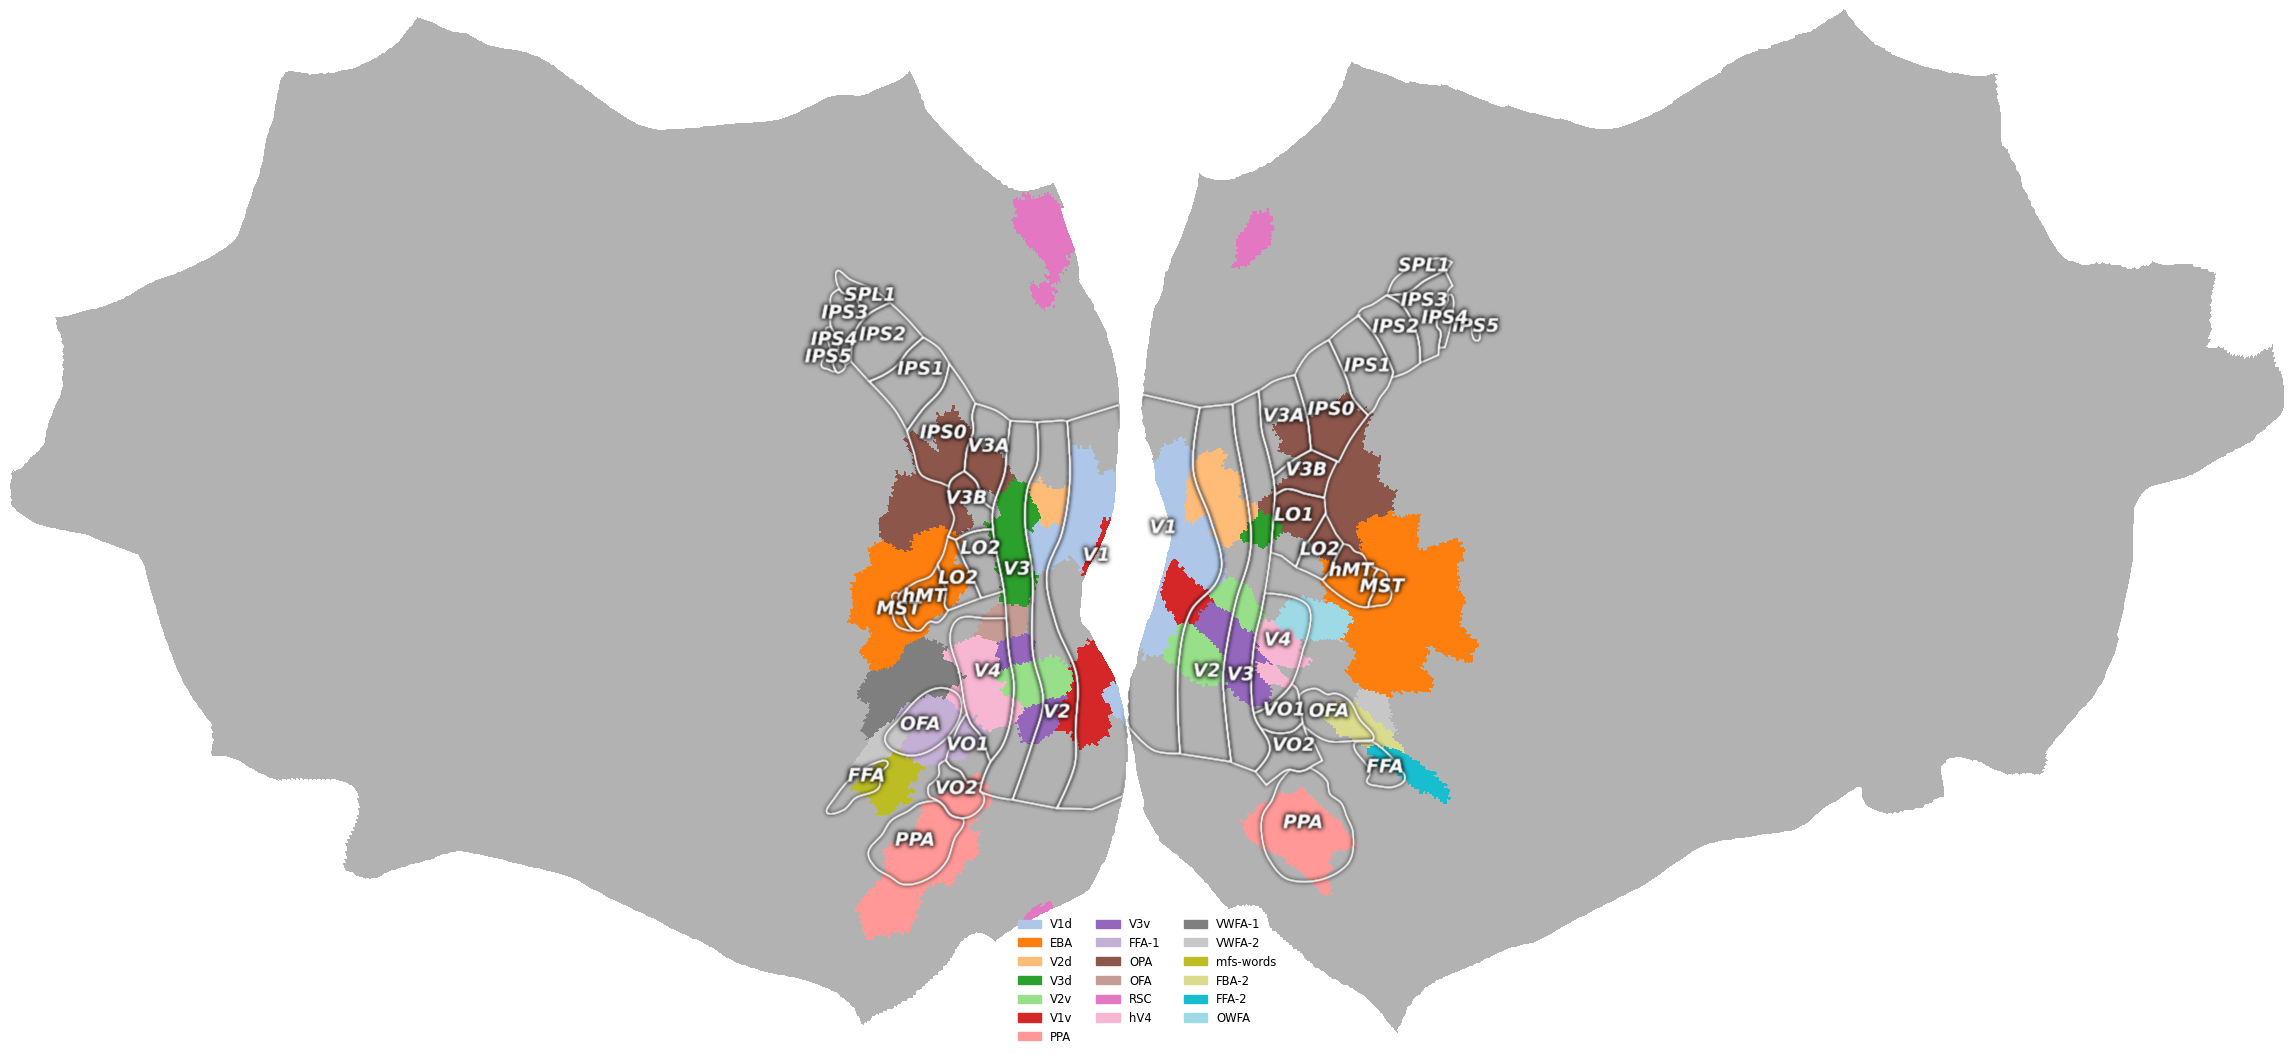

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cortex

def visualize_parcels_by_roi(
    dataset, metadata, dominant_rois, all_roi_names, subject="fsaverage",
    unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0),
    with_curvature=True, legend_cols=3
):
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)

    # 1) Collect only matched ROIs (skip None)
    matched_roi_order = []
    seen = set()
    for hemi in ("lh", "rh"):
        for (_pid, roi_name, _overlap, _nvox) in dominant_rois[hemi]:
            if roi_name is not None and roi_name not in seen:
                seen.add(roi_name)
                matched_roi_order.append(roi_name)

    # Compact mapping: 0 = unlabeled (gray), 1..K = matched ROIs
    roi_list = [unlabeled_name] + matched_roi_order
    roi_to_idx = {name: i for i, name in enumerate(roi_list)}

    # 2) Hemisphere sizes
    lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
    rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))

    # 3) Init labels
    lh_labels = np.zeros(lh_hemi_size, dtype=np.int32)
    rh_labels = np.zeros(rh_hemi_size, dtype=np.int32)

    # 4) Paint parcels
    sel_vox = dataset.get_selected_voxel_indices()
    for hemi, labels in (("lh", lh_labels), ("rh", rh_labels)):
        for pos, (_pid, roi_name, _overlap, _nvox) in enumerate(dominant_rois[hemi]):
            vox = sel_vox[hemi][pos]
            vox = vox.cpu().numpy() if isinstance(vox, torch.Tensor) else np.asarray(vox)
            if vox.size == 0:
                continue
            idx = roi_to_idx.get(roi_name, 0) if roi_name is not None else 0
            labels[vox] = idx

    # 5) Discrete colormap for ONLY matched ROIs (+ unlabeled gray)
    base = plt.cm.tab20(np.linspace(0, 1, 20))
    need = max(1, len(roi_list) - 1)                  # number of matched ROIs
    reps = int(np.ceil(need / 19.0))
    palette = np.vstack([base[1:],] * reps)[:need]    # skip one for variety
    cmap = ListedColormap(np.vstack([np.array(unlabeled_color)[None, :], palette]))

    # 6) Visualize with pycortex (no internal colorbar)
    data = np.append(lh_labels, rh_labels)
    v = cortex.Vertex(data, subject=subject, cmap=cmap, vmin=0, vmax=len(roi_list)-1)
    with suppress_print():
        cortex.quickshow(v, with_curvature=with_curvature, with_colorbar=False)

    # 7) Build a categorical legend showing ONLY matched ROIs
    patches = []
    for i, name in enumerate(roi_list):
        if i == 0:
            continue  # skip unlabeled in legend
        patches.append(mpatches.Patch(color=cmap(i), label=name))

    # Place legend below figure
    fig = plt.gcf()
    if patches:
        fig.legend(
            handles=patches,
            loc="lower center",
            ncol=min(legend_cols, len(patches)),
            fontsize="small",
            frameon=False,
            bbox_to_anchor=(0.5, -0.02)
        )
        plt.subplots_adjust(bottom=0.18)  # make room for legend

    # plt.title("Schaefer parcels colored by matched ROIs (unlabeled in gray)")
    plt.show()

visualize_parcels_by_roi(train_dataset, metadata, dominant_rois, all_roi_names, subject="fsaverage",
                             unlabeled_name="(unlabeled)", unlabeled_color=(0.7,0.7,0.7,1.0))


In [6]:
attn_file = "brain_adapter/attn_maps/08_14_2025-00_21/epoch_200/subset/sample_000000/time_step_101.npz"

npz_data = np.load(attn_file, allow_pickle=True)

time_step = int(attn_file.split("/")[-1].replace(".npz", "").split("_")[-1])
attn_maps = npz_data['attention_maps'].item()
noisy_preds = npz_data['noisy_images']
clean_preds = npz_data['clean_predictions']
layer_names = npz_data['layer_names']
print(time_step)
print(noisy_preds.shape)
print(clean_preds.shape)
print(layer_names)

101
(1, 512, 512, 3)
(1, 512, 512, 3)
['down_blocks.0.attentions.0.transformer_blocks.0.attn2'
 'mid_block.attentions.0.transformer_blocks.0.attn2'
 'up_blocks.3.attentions.2.transformer_blocks.0.attn2']


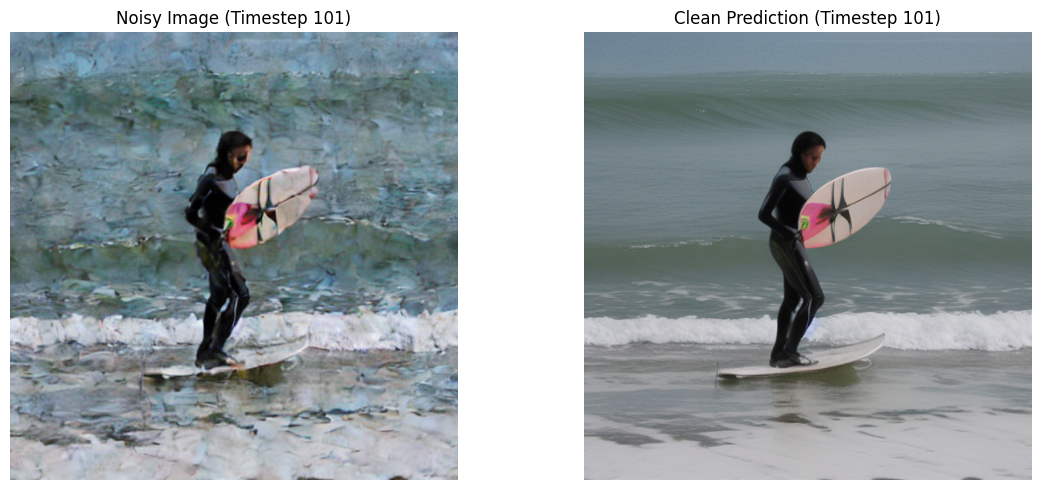

Noisy image range: [0, 250]
Clean prediction range: [2, 237]


In [7]:
# Plot the noisy and clean prediction images
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot noisy image
axes[0].imshow(noisy_preds[0])  # Remove batch dimension if present
axes[0].set_title(f'Noisy Image (Timestep {time_step})')
axes[0].axis('off')

# Plot clean prediction
axes[1].imshow(clean_preds[0])  # Remove batch dimension if present
axes[1].set_title(f'Clean Prediction (Timestep {time_step})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Print some info about the images
print(f"Noisy image range: [{noisy_preds.min():.0f}, {noisy_preds.max():.0f}]")
print(f"Clean prediction range: [{clean_preds.min():.0f}, {clean_preds.max():.0f}]")

In [8]:
layer = layer_names[1]
attn_map = attn_maps[layer]['ip_attn_map']
print(attn_map.shape)
batch_size = attn_map.shape[0]
if batch_size == 2:
    attn_map = attn_map[1]  # Select the conditional attention map


(2, 8, 64, 200)


Attention shape: 8 heads, 64 spatial, 200 condition tokens
Final attention weights shape: (200,)
Normalized 104 ROI weights (originally summed to 0.5335)


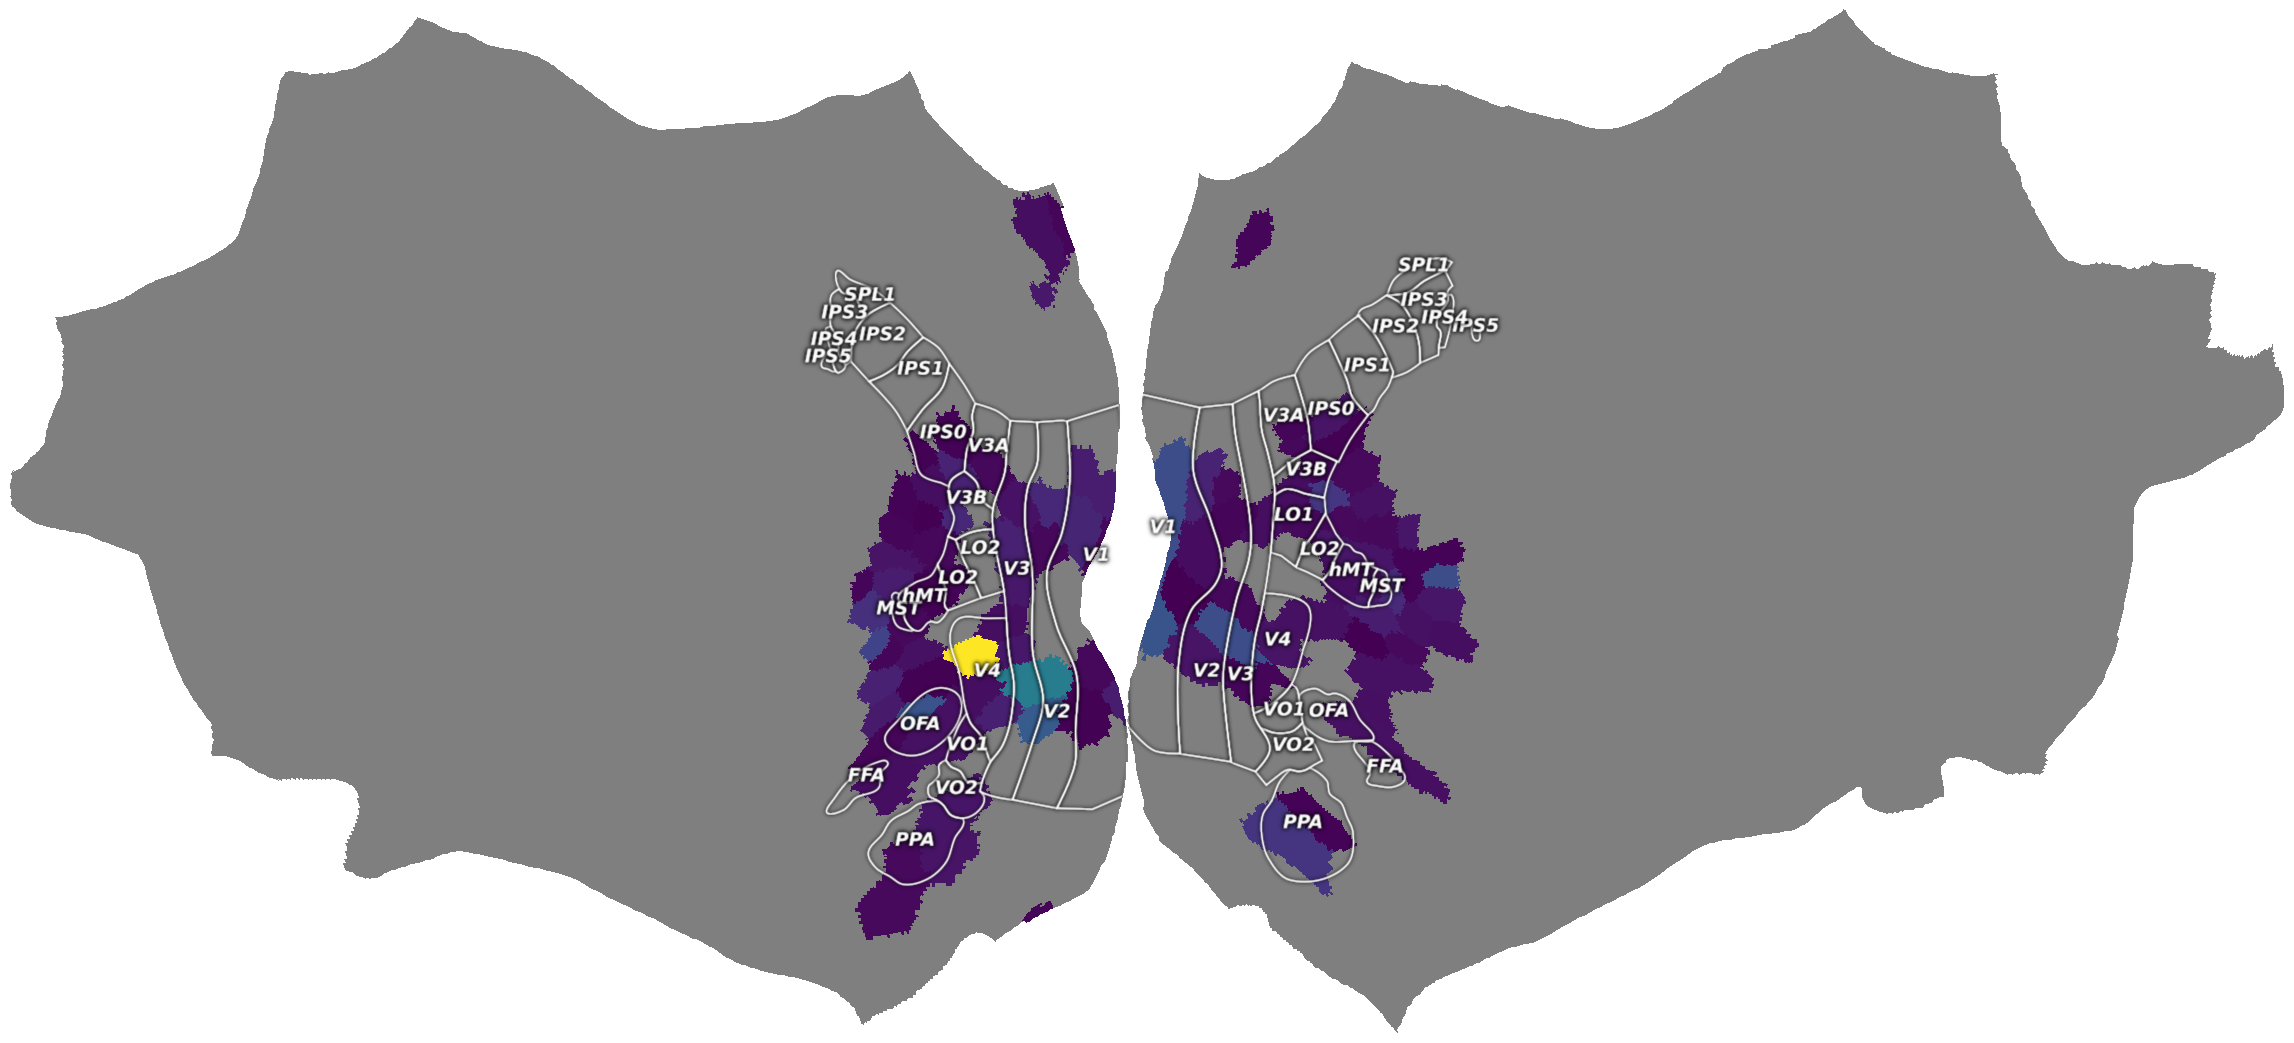

ROI statistics:
  Total condition tokens: 200
  Tokens with ROI labels: 104
  Tokens without ROI: 96
  Percentage with ROI: 52.0%
  Normalized ROI weights sum: 1.0000
Non-zero attention weights: 26681 voxels
Attention range: [0.0000, 0.1136]
Unlabeled (grey) voxels: 301003 voxels
Mean attention (non-zero): 0.0098


In [9]:
def visualize_attention_on_cortex(
    attn_map, train_dataset, metadata, dominant_rois, 
    spatial_idx=None, head_idx=None, subject="fsaverage", 
    cmap='viridis', with_curvature=True, normalize_roi_weights=True
):
    """
    Paint attention weights onto cortical surface using Pycortex.
    
    Args:
        attn_map: Attention tensor [num_heads, spatial_tokens, condition_tokens] 
        train_dataset: Dataset with parcel information
        metadata: Brain metadata with ROI mappings
        dominant_rois: ROI assignments per parcel
        spatial_idx: Which spatial token to visualize (default: average all)
        head_idx: Which attention head to visualize (default: average all heads)
        subject: Pycortex subject name
        cmap: Colormap for visualization
        with_curvature: Whether to show cortical curvature
        normalize_roi_weights: Whether to renormalize weights for only valid ROI parcels
    """
    # Ensure subject exists
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)
    
    # Handle attention map dimensions
    if attn_map.ndim == 4:  # [batch, heads, spatial, tokens]
        attn_map = attn_map[1]  # we select conditional attention map
    
    num_heads, spatial_tokens, condition_tokens = attn_map.shape
    print(f"Attention shape: {num_heads} heads, {spatial_tokens} spatial, {condition_tokens} condition tokens")
    
    # Select which spatial token and head to visualize
    if spatial_idx is None:
        # Average across all spatial tokens
        attn_weights = attn_map.mean(axis=1)  # [heads, tokens]
    else:
        attn_weights = attn_map[:, spatial_idx, :]  # [heads, tokens]
    
    if head_idx is None:
        # Average across all heads
        attn_weights = attn_weights.mean(axis=0)  # [tokens]
    else:
        attn_weights = attn_weights[head_idx, :]  # [tokens]
    
    print(f"Final attention weights shape: {attn_weights.shape}")
    
    # Get hemisphere sizes
    lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
    rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))
    
    # Initialize cortical surface with zeros
    lh_values = np.zeros(lh_hemi_size, dtype=np.float32)
    rh_values = np.zeros(rh_hemi_size, dtype=np.float32)
    
    # Get selected voxel indices for each parcel
    sel_vox = train_dataset.get_selected_voxel_indices()
    
    # First pass: collect weights for valid ROI parcels to compute normalization
    valid_roi_weights = []
    roi_token_indices = []
    
    for hemi in ["lh", "rh"]:
        for parcel_pos, (parcel_idx, roi_name, overlap, nvox) in enumerate(dominant_rois[hemi]):
            if roi_name is not None:  # Only parcels with ROI labels
                # Calculate token index (LH: 0-99, RH: 100-199)
                if hemi == "lh":
                    token_idx = parcel_pos
                else:
                    token_idx = parcel_pos + 100
                
                if token_idx < len(attn_weights):
                    valid_roi_weights.append(attn_weights[token_idx])
                    roi_token_indices.append(token_idx)
    
    valid_roi_weights = np.array(valid_roi_weights)
    
    # Normalize weights if requested
    if normalize_roi_weights and len(valid_roi_weights) > 0:
        weight_sum = valid_roi_weights.sum()
        if weight_sum > 0:
            # Renormalize so valid ROI weights sum to 1
            valid_roi_weights = valid_roi_weights / weight_sum
            print(f"Normalized {len(valid_roi_weights)} ROI weights (originally summed to {weight_sum:.4f})")
        else:
            print("Warning: All ROI weights are zero, skipping normalization")
    
    # Create mapping from token index to normalized weight
    token_to_weight = dict(zip(roi_token_indices, valid_roi_weights))
    
    # Paint attention weights onto cortical surface
    for hemi, values in [("lh", lh_values), ("rh", rh_values)]:
        for parcel_pos, (parcel_idx, roi_name, overlap, nvox) in enumerate(dominant_rois[hemi]):
            
            if roi_name is None:
                continue
            
            # Get voxel indices for this parcel
            vox_indices = sel_vox[hemi][parcel_pos]
            vox_indices = vox_indices.cpu().numpy() if isinstance(vox_indices, torch.Tensor) else np.asarray(vox_indices)
            
            if vox_indices.size == 0:
                continue
            
            # Calculate token index (LH: 0-99, RH: 100-199)
            if hemi == "lh":
                token_idx = parcel_pos
            else:
                token_idx = parcel_pos + 100  # RH tokens start at index 100
            
            # Get (potentially normalized) attention weight for this token
            if token_idx in token_to_weight:
                weight = token_to_weight[token_idx]
                # Paint this weight onto all voxels in the parcel
                values[vox_indices] = weight
    
    # Combine hemispheres for Pycortex
    cortex_data = np.concatenate([lh_values, rh_values])
    
    # Create a custom colormap: grey for unlabeled (0), viridis for labeled areas
    from matplotlib.colors import ListedColormap
    import matplotlib.pyplot as plt
    
    # Get the viridis colormap
    viridis = plt.cm.viridis
    n_colors = 256
    
    # Create custom colormap: first color is grey, rest is viridis
    colors = np.zeros((n_colors + 1, 4))
    colors[0] = [0.5, 0.5, 0.5, 1.0]  # Grey for unlabeled areas (value = 0)
    colors[1:] = viridis(np.linspace(0, 1, n_colors))  # Viridis for labeled areas
    
    custom_cmap = ListedColormap(colors)
    
    # Adjust data: shift non-zero values to start from 1 instead of their original range
    cortex_data_adjusted = cortex_data.copy()
    non_zero_mask = cortex_data > 0
    
    if np.any(non_zero_mask):
        # Normalize non-zero values to range [1, n_colors] 
        min_val = cortex_data[non_zero_mask].min()
        max_val = cortex_data[non_zero_mask].max()
        
        if max_val > min_val:
            # Scale to [1, n_colors]
            cortex_data_adjusted[non_zero_mask] = 1 + (n_colors - 1) * (cortex_data[non_zero_mask] - min_val) / (max_val - min_val)
        else:
            # All non-zero values are the same
            cortex_data_adjusted[non_zero_mask] = n_colors // 2
    
    # Create Pycortex vertex object with custom colormap
    vertex_data = cortex.Vertex(
        cortex_data_adjusted, 
        subject=subject, 
        cmap=custom_cmap,
        vmin=0,
        vmax=n_colors
    )
    
    # Visualize with clean appearance - no colorbar
    with suppress_print():
        cortex.quickshow(vertex_data, with_curvature=with_curvature, with_colorbar=False)
    
    # Beautify the plot
    fig = plt.gcf()
    
    # Remove any default axes/spines for cleaner look
    for ax in fig.get_axes():
        ax.set_frame_on(False)
        ax.set_xticks([])
        ax.set_yticks([])
    
    plt.show()
    
    # Print statistics
    num_valid_rois = len(valid_roi_weights)
    total_tokens = len(attn_weights)
    tokens_without_roi = total_tokens - num_valid_rois
    
    print(f"ROI statistics:")
    print(f"  Total condition tokens: {total_tokens}")
    print(f"  Tokens with ROI labels: {num_valid_rois}")
    print(f"  Tokens without ROI: {tokens_without_roi}")
    print(f"  Percentage with ROI: {num_valid_rois/total_tokens*100:.1f}%")
    
    if normalize_roi_weights:
        print(f"  Normalized ROI weights sum: {valid_roi_weights.sum():.4f}")
    else:
        print(f"  Original ROI weights sum: {valid_roi_weights.sum():.4f}")
    
    print(f"Non-zero attention weights: {np.sum(cortex_data > 0)} voxels")
    print(f"Attention range: [{cortex_data.min():.4f}, {cortex_data.max():.4f}]")
    print(f"Unlabeled (grey) voxels: {np.sum(cortex_data == 0)} voxels")
    if np.any(cortex_data > 0):
        print(f"Mean attention (non-zero): {cortex_data[cortex_data > 0].mean():.4f}")
    
    return cortex_data

# Example usage: Visualize attention weights on cortex
cortex_attention = visualize_attention_on_cortex(
    attn_map, train_dataset, metadata, dominant_rois,
    spatial_idx=None,  # Average across all spatial tokens
    head_idx=None,     # Average across all attention heads
    subject="fsaverage",
    cmap='viridis',
    normalize_roi_weights=True  # Renormalize weights for valid ROI parcels only
)

In [ ]:
import imageio.v2 as imageio
import glob
import re
from pathlib import Path

def create_denoising_timeline_visualization(
    sample_id, 
    base_dir="brain_adapter/attn_maps/08_14_2025-00_21/epoch_200/subset",
    train_dataset=None, 
    metadata=None, 
    dominant_rois=None,
    subject="fsaverage",
    layer_name=None,  # If None, will use the first available layer
    spatial_idx=None,  # If None, average across spatial tokens
    head_idx=None,     # If None, average across heads
    save_gif=True,
    gif_filename=None,
    fps=6,
    max_timesteps=None  # Limit number of timesteps for faster processing
):
    """
    Create a comprehensive timeline visualization of the denoising process showing:
    1. Noisy images across timesteps
    2. Clean predictions across timesteps  
    3. Brain surface attention mappings across timesteps
    
    Args:
        sample_id: Sample identifier (e.g., "000000")
        base_dir: Base directory containing attention maps
        train_dataset: Dataset with parcel information
        metadata: Brain metadata with ROI mappings
        dominant_rois: ROI assignments per parcel
        subject: Pycortex subject name
        layer_name: Which attention layer to visualize (None = use first available)
        spatial_idx: Which spatial token to visualize (None = average all)
        head_idx: Which attention head to visualize (None = average all)
        save_gif: Whether to save as animated GIF
        gif_filename: Custom filename for GIF (None = auto-generate)
        fps: Frames per second for GIF
        max_timesteps: Maximum number of timesteps to process (None = all)
    
    Returns:
        Dictionary with timestep data and file paths
    """
    
    # Ensure subject exists for pycortex
    if subject not in cortex.db.subjects:
        cortex.download_subject(subject)
    
    # Construct sample directory path
    sample_dir = Path(base_dir) / f"sample_{sample_id:06d}"
    
    if not sample_dir.exists():
        raise FileNotFoundError(f"Sample directory not found: {sample_dir}")
    
    # Get all timestep files and sort them numerically
    timestep_files = list(sample_dir.glob("time_step_*.npz"))
    
    def extract_timestep(filename):
        match = re.search(r'time_step_(\d+)\.npz', str(filename))
        return int(match.group(1)) if match else 0
    
    timestep_files.sort(key=extract_timestep)
    
    if max_timesteps is not None:
        timestep_files = timestep_files[:max_timesteps]
    
    print(f"Processing {len(timestep_files)} timesteps for sample {sample_id}")
    
    # Storage for all timeline data
    timeline_data = {
        'timesteps': [],
        'noisy_images': [],
        'clean_images': [],
        'cortex_frames': [],
        'attention_stats': []
    }
    
    # Process each timestep
    vmin_global, vmax_global = None, None  # For consistent cortex scaling
    
    # First pass: collect attention weight ranges for consistent scaling
    print("Computing global attention weight range...")
    all_attention_weights = []
    
    for timestep_file in timestep_files[:5]:  # Sample first 5 for range estimation
        try:
            npz_data = np.load(timestep_file, allow_pickle=True)
            attn_maps = npz_data['attention_maps'].item()
            
            # Use first available layer if none specified
            if layer_name is None:
                layer_name = list(attn_maps.keys())[0]
            
            if layer_name in attn_maps:
                attn_map = attn_maps[layer_name]['ip_attn_map']
                
                # Handle batch dimension
                if attn_map.shape[0] == 2:
                    attn_map = attn_map[1]  # Use conditional attention
                
                # Process attention weights
                if spatial_idx is None:
                    attn_weights = attn_map.mean(axis=1)  # Average across spatial
                else:
                    attn_weights = attn_map[:, spatial_idx, :]
                
                if head_idx is None:
                    attn_weights = attn_weights.mean(axis=0)  # Average across heads
                else:
                    attn_weights = attn_weights[head_idx, :]
                
                all_attention_weights.extend(attn_weights.flatten())
        except Exception as e:
            print(f"Warning: Could not process {timestep_file} for range estimation: {e}")
            continue
    
    if all_attention_weights:
        vmin_global = np.min(all_attention_weights)
        vmax_global = np.max(all_attention_weights)
        print(f"Global attention range: [{vmin_global:.4f}, {vmax_global:.4f}]")
    else:
        vmin_global, vmax_global = 0.0, 1.0
        print("Warning: Could not determine attention range, using [0, 1]")
    
    # Second pass: create visualizations
    print("Creating timeline visualizations...")
    
    for i, timestep_file in enumerate(timestep_files):
        try:
            # Load timestep data
            npz_data = np.load(timestep_file, allow_pickle=True)
            timestep = extract_timestep(timestep_file)
            
            # Extract images
            noisy_images = npz_data.get('noisy_images', None)
            clean_predictions = npz_data.get('clean_predictions', None)
            attn_maps = npz_data['attention_maps'].item()
            
            # Store basic data
            timeline_data['timesteps'].append(timestep)
            
            if noisy_images is not None:
                timeline_data['noisy_images'].append(noisy_images[0])  # Remove batch dim
            else:
                timeline_data['noisy_images'].append(None)
                
            if clean_predictions is not None:
                timeline_data['clean_images'].append(clean_predictions[0])  # Remove batch dim
            else:
                timeline_data['clean_images'].append(None)
            
            # Process attention for cortex visualization
            if layer_name in attn_maps:
                attn_map = attn_maps[layer_name]['ip_attn_map']
                
                # Handle batch dimension
                if attn_map.shape[0] == 2:
                    attn_map = attn_map[1]  # Use conditional attention
                
                # Create cortex visualization (modified from existing function)
                cortex_data = create_cortex_attention_frame(
                    attn_map, train_dataset, metadata, dominant_rois,
                    spatial_idx=spatial_idx, head_idx=head_idx,
                    subject=subject, vmin=vmin_global, vmax=vmax_global
                )
                
                timeline_data['cortex_frames'].append(cortex_data['frame'])
                timeline_data['attention_stats'].append(cortex_data['stats'])
                
            else:
                print(f"Warning: Layer {layer_name} not found in timestep {timestep}")
                timeline_data['cortex_frames'].append(None)
                timeline_data['attention_stats'].append(None)
                
            # Progress update
            if (i + 1) % 10 == 0:
                print(f"Processed {i + 1}/{len(timestep_files)} timesteps")
                
        except Exception as e:
            print(f"Error processing timestep {timestep_file}: {e}")
            # Add None placeholders to maintain alignment
            timeline_data['noisy_images'].append(None)
            timeline_data['clean_images'].append(None)
            timeline_data['cortex_frames'].append(None)
            timeline_data['attention_stats'].append(None)
            continue
    
    # Create composite visualization
    print("Creating composite visualization...")
    composite_frames = create_composite_timeline_frames(timeline_data)
    
    # Save as GIF if requested
    if save_gif and composite_frames:
        if gif_filename is None:
            gif_filename = f"denoising_timeline_sample_{sample_id}.gif"
        
        print(f"Saving animated GIF: {gif_filename}")
        imageio.mimsave(gif_filename, composite_frames, fps=fps)
        print(f"GIF saved with {len(composite_frames)} frames at {fps} FPS")
    
    # Display final summary
    print(f"\nTimeline Summary for Sample {sample_id}:")
    print(f"  Total timesteps processed: {len(timeline_data['timesteps'])}")
    print(f"  Timestep range: {min(timeline_data['timesteps'])} - {max(timeline_data['timesteps'])}")
    print(f"  Layer used: {layer_name}")
    if spatial_idx is not None:
        print(f"  Spatial token: {spatial_idx}")
    else:
        print(f"  Spatial tokens: averaged across all")
    if head_idx is not None:
        print(f"  Attention head: {head_idx}")
    else:
        print(f"  Attention heads: averaged across all")
    
    return {
        'timeline_data': timeline_data,
        'composite_frames': composite_frames,
        'gif_filename': gif_filename if save_gif else None,
        'sample_id': sample_id,
        'layer_name': layer_name
    }


def create_cortex_attention_frame(
    attn_map, train_dataset, metadata, dominant_rois,
    spatial_idx=None, head_idx=None, subject="fsaverage",
    vmin=None, vmax=None
):
    """
    Create a single cortex attention frame for timeline visualization.
    Modified from the main visualize_attention_on_cortex function.
    """
    
    # Handle attention map dimensions
    num_heads, spatial_tokens, condition_tokens = attn_map.shape
    
    # Select which spatial token and head to visualize
    if spatial_idx is None:
        attn_weights = attn_map.mean(axis=1)  # [heads, tokens]
    else:
        attn_weights = attn_map[:, spatial_idx, :]  # [heads, tokens]
    
    if head_idx is None:
        attn_weights = attn_weights.mean(axis=0)  # [tokens]
    else:
        attn_weights = attn_weights[head_idx, :]  # [tokens]
    
    # Get hemisphere sizes
    lh_hemi_size = len(next(iter(metadata['lh_rois'].values())))
    rh_hemi_size = len(next(iter(metadata['rh_rois'].values())))
    
    # Initialize cortical surface with zeros
    lh_values = np.zeros(lh_hemi_size, dtype=np.float32)
    rh_values = np.zeros(rh_hemi_size, dtype=np.float32)
    
    # Get selected voxel indices for each parcel
    sel_vox = train_dataset.get_selected_voxel_indices()
    
    # Collect weights for valid ROI parcels
    valid_roi_weights = []
    roi_token_indices = []
    
    for hemi in ["lh", "rh"]:
        for parcel_pos, (parcel_idx, roi_name, overlap, nvox) in enumerate(dominant_rois[hemi]):
            if roi_name is not None:
                if hemi == "lh":
                    token_idx = parcel_pos
                else:
                    token_idx = parcel_pos + 100
                
                if token_idx < len(attn_weights):
                    valid_roi_weights.append(attn_weights[token_idx])
                    roi_token_indices.append(token_idx)
    
    valid_roi_weights = np.array(valid_roi_weights)
    
    # Normalize weights for valid ROI parcels only
    if len(valid_roi_weights) > 0:
        weight_sum = valid_roi_weights.sum()
        if weight_sum > 0:
            valid_roi_weights = valid_roi_weights / weight_sum
    
    # Create mapping from token index to normalized weight
    token_to_weight = dict(zip(roi_token_indices, valid_roi_weights))
    
    # Paint attention weights onto cortical surface
    for hemi, values in [("lh", lh_values), ("rh", rh_values)]:
        for parcel_pos, (parcel_idx, roi_name, overlap, nvox) in enumerate(dominant_rois[hemi]):
            if roi_name is None:
                continue
            
            vox_indices = sel_vox[hemi][parcel_pos]
            vox_indices = vox_indices.cpu().numpy() if isinstance(vox_indices, torch.Tensor) else np.asarray(vox_indices)
            
            if vox_indices.size == 0:
                continue
            
            if hemi == "lh":
                token_idx = parcel_pos
            else:
                token_idx = parcel_pos + 100
            
            if token_idx in token_to_weight:
                weight = token_to_weight[token_idx]
                values[vox_indices] = weight
    
    # Combine hemispheres for Pycortex
    cortex_data = np.concatenate([lh_values, rh_values])
    
    # Create custom colormap: grey for unlabeled, viridis for labeled
    from matplotlib.colors import ListedColormap
    viridis = plt.cm.viridis
    n_colors = 256
    
    colors = np.zeros((n_colors + 1, 4))
    colors[0] = [0.5, 0.5, 0.5, 1.0]  # Grey for unlabeled
    colors[1:] = viridis(np.linspace(0, 1, n_colors))
    
    custom_cmap = ListedColormap(colors)
    
    # Adjust data for custom colormap
    cortex_data_adjusted = cortex_data.copy()
    non_zero_mask = cortex_data > 0
    
    if np.any(non_zero_mask):
        if vmin is not None and vmax is not None and vmax > vmin:
            # Use global scaling
            cortex_data_adjusted[non_zero_mask] = 1 + (n_colors - 1) * np.clip(
                (cortex_data[non_zero_mask] - vmin) / (vmax - vmin), 0, 1
            )
        else:
            # Local scaling
            min_val = cortex_data[non_zero_mask].min()
            max_val = cortex_data[non_zero_mask].max()
            if max_val > min_val:
                cortex_data_adjusted[non_zero_mask] = 1 + (n_colors - 1) * (cortex_data[non_zero_mask] - min_val) / (max_val - min_val)
            else:
                cortex_data_adjusted[non_zero_mask] = n_colors // 2
    
    # Create Pycortex vertex and render
    vertex_data = cortex.Vertex(
        cortex_data_adjusted, 
        subject=subject, 
        cmap=custom_cmap,
        vmin=0,
        vmax=n_colors
    )
    
    # Render to frame
    with suppress_print():
        fig = cortex.quickflat.make_figure(vertex_data, with_curvature=True, with_colorbar=False)
    
    fig.canvas.draw()
    # Use buffer_rgba instead of deprecated tostring_rgb
    try:
        frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (4,))
        frame = frame[:, :, :3]  # Remove alpha channel
    except AttributeError:
        # Fallback for older matplotlib versions
        frame = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        frame = frame.reshape(fig.canvas.get_width_height()[::-1] + (3,))
    plt.close(fig)
    
    # Calculate statistics
    stats = {
        'num_valid_rois': len(valid_roi_weights),
        'total_tokens': len(attn_weights),
        'attention_range': (cortex_data.min(), cortex_data.max()),
        'mean_attention': cortex_data[cortex_data > 0].mean() if np.any(cortex_data > 0) else 0.0
    }
    
    return {'frame': frame, 'stats': stats}


def create_composite_timeline_frames(timeline_data):
    """
    Create composite frames combining noisy images, clean predictions, and cortex visualizations.
    """
    
    composite_frames = []
    n_timesteps = len(timeline_data['timesteps'])
    
    for i in range(n_timesteps):
        # Get components for this timestep
        timestep = timeline_data['timesteps'][i]
        noisy_img = timeline_data['noisy_images'][i]
        clean_img = timeline_data['clean_images'][i]
        cortex_frame = timeline_data['cortex_frames'][i]
        
        # Skip if any component is missing
        if noisy_img is None or clean_img is None or cortex_frame is None:
            continue
        
        # Ensure images are uint8
        if noisy_img.dtype != np.uint8:
            noisy_img = (np.clip(noisy_img, 0, 1) * 255).astype(np.uint8)
        if clean_img.dtype != np.uint8:
            clean_img = (np.clip(clean_img, 0, 1) * 255).astype(np.uint8)
        
        # Resize images to consistent size (e.g., 512x512)
        target_size = (512, 512)
        noisy_resized = resize_image_array(noisy_img, target_size)
        clean_resized = resize_image_array(clean_img, target_size)
        
        # Resize cortex frame to match
        cortex_resized = resize_image_array(cortex_frame, target_size)
        
        # Create composite frame
        gap = 10  # Gap between images
        composite_width = target_size[1] * 3 + gap * 2
        composite_height = target_size[0] + 60  # Extra space for title
        
        composite = np.ones((composite_height, composite_width, 3), dtype=np.uint8) * 255
        
        # Place images
        composite[30:30+target_size[0], 0:target_size[1]] = noisy_resized
        composite[30:30+target_size[0], target_size[1]+gap:target_size[1]*2+gap] = clean_resized
        composite[30:30+target_size[0], target_size[1]*2+gap*2:target_size[1]*3+gap*2] = cortex_resized
        
        # Add title
        title = f"Timestep {timestep:3d}"
        # Simple text rendering - you could use PIL for better text
        
        composite_frames.append(composite)
    
    return composite_frames


def resize_image_array(img, target_size):
    """Simple image resizing using numpy interpolation."""
    try:
        from PIL import Image
        # Convert numpy array to PIL Image
        if len(img.shape) == 2:  # Grayscale
            pil_img = Image.fromarray(img, mode='L')
        else:  # RGB
            pil_img = Image.fromarray(img, mode='RGB')
        
        # Resize using PIL
        resized_pil = pil_img.resize((target_size[1], target_size[0]), Image.LANCZOS)
        
        # Convert back to numpy array
        return np.array(resized_pil)
    
    except ImportError:
        # Fallback to simple numpy-based resizing
        print("PIL not available, using simple numpy resizing")
        h, w = img.shape[:2]
        target_h, target_w = target_size
        
        # Simple nearest neighbor resizing
        y_ratio = h / target_h
        x_ratio = w / target_w
        
        if len(img.shape) == 2:  # Grayscale
            resized = np.zeros((target_h, target_w), dtype=img.dtype)
            for i in range(target_h):
                for j in range(target_w):
                    resized[i, j] = img[int(i * y_ratio), int(j * x_ratio)]
        else:  # RGB
            resized = np.zeros((target_h, target_w, img.shape[2]), dtype=img.dtype)
            for i in range(target_h):
                for j in range(target_w):
                    resized[i, j] = img[int(i * y_ratio), int(j * x_ratio)]
        
        return resized

# Example usage
print("Functions defined. Ready to create denoising timeline visualization!")

Functions defined. Ready to create denoising timeline visualization!


In [13]:
# Create denoising timeline visualization for sample 000000
sample_id = "000000"

print(f"Creating denoising timeline visualization for sample {sample_id}")
print("This will process all timesteps and create a comprehensive visualization...")

# Run the timeline visualization  
result = create_denoising_timeline_visualization(
    sample_id=sample_id,
    base_dir="brain_adapter/attn_maps/08_14_2025-00_21/epoch_200/subset",
    train_dataset=train_dataset,
    metadata=metadata,
    dominant_rois=dominant_rois,
    subject="fsaverage",
    layer_name=None,  # Will use first available layer
    spatial_idx=None,  # Average across all spatial tokens
    head_idx=None,     # Average across all attention heads
    save_gif=True,
    gif_filename=f"denoising_timeline_sample_{sample_id}.gif",
    fps=6,
    max_timesteps=10  # Limit to first 10 timesteps for faster demo
)

print(f"\nVisualization complete!")
print(f"GIF saved: {result['gif_filename']}")
print(f"Total frames created: {len(result['composite_frames'])}")

Creating denoising timeline visualization for sample 000000
This will process all timesteps and create a comprehensive visualization...
Processing 10 timesteps for sample 000000
Computing global attention weight range...
Global attention range: [0.0012, 0.0261]
Creating timeline visualizations...
Global attention range: [0.0012, 0.0261]
Creating timeline visualizations...
Processed 10/10 timesteps
Creating composite visualization...
Processed 10/10 timesteps
Creating composite visualization...
Saving animated GIF: denoising_timeline_sample_000000.gif
Saving animated GIF: denoising_timeline_sample_000000.gif
GIF saved with 10 frames at 6 FPS

Timeline Summary for Sample 000000:
  Total timesteps processed: 10
  Timestep range: 1 - 181
  Layer used: down_blocks.0.attentions.0.transformer_blocks.0.attn2
  Spatial tokens: averaged across all
  Attention heads: averaged across all

Visualization complete!
GIF saved: denoising_timeline_sample_000000.gif
Total frames created: 10
GIF saved wit